## Model Isinga z numbą

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import numba as nb
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random

In [14]:
@nb.njit
def hamiltonian_cell(state, i, j, J, B):
    height, width = state.shape
    H = 0

    for di in range(-1,2):
        for dj in range(-1,2):
            if (di == 0) and (dj == 0):
                continue
            ni = (i + di) % height
            nj = (j + dj) % width
            H -= J * state[i, j] * state[ni, nj]
    
    H = H/2
    
    H -= B * state[i, j]

    return H

In [15]:
@nb.njit
def hamiltonian(state, J, B):
    height, width = state.shape
    H = 0

    for i in range(height):
        for j in range(width):
            H += hamiltonian_cell(state, i, j, J, B)

    return H

In [16]:
@nb.njit
def mag(state):
    suma = 0
    height, width = state.shape
    for i in range(height):
        for j in range(width):
            suma += state[i, j]
    
    return suma/(height*width)

In [17]:
@nb.njit
def change_spin(state, J, B, beta):
    height, width = state.shape
    ri = random.randint(0, height - 1)
    rj = random.randint(0, width - 1)
    r = random.random()

    E0 = hamiltonian_cell(state, ri, rj, J, B) # energia przed zmianą spinu
    E1 = E0 * (-1) # enrgia po zmianie spinu

    # energia mniejsza po zmianie
    if E1 <= E0:
        state[ri, rj] = (-1) * state[ri, rj]
        
    # energia większa po zmianie
    else:
        p = np.exp(-beta * (E1 - E0))
        if r <= p:
            state[ri, rj] = (-1) * state[ri, rj]

    return state

In [18]:
J = 1
B = 1
beta = 0.001
step_count = 500

In [19]:
@nb.njit
def next_state(state,n):

    for _ in range(n*n):
        state = change_spin(state, 1, 0, 100)
    
    return state

In [20]:
def calculate_steps(steps, n):
    state = np.random.choice([-1,1],(n,n))

    history = [state.copy()]
    for _ in range(steps):
        next_state(state, n)
        history.append(state.copy())

    return history

In [21]:
states = calculate_steps(step_count,100)

In [22]:
fig = plt.figure(figsize=(4,4))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.axis('off')

img = plt.imshow(states[0])

plt.close()

def update(i):
    img.set_data(states[i])
    return img,

ani = FuncAnimation(fig,update,frames=len(states),interval=100,blit=True)
HTML(ani.to_jshtml())

<function matplotlib.pyplot.show(close=None, block=None)>

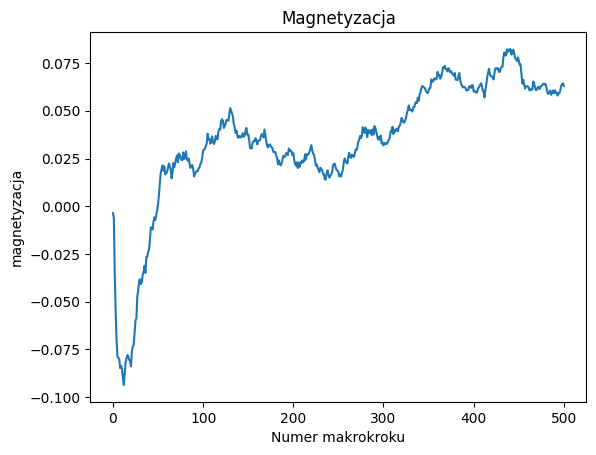

In [23]:
xm = np.arange(0,step_count+1)
ym = []

for i in range(step_count+1):
    ym.append(mag(states[i]))

plt.plot(xm,ym)
plt.title('Magnetyzacja')
plt.xlabel('Numer makrokroku')
plt.ylabel('magnetyzacja')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

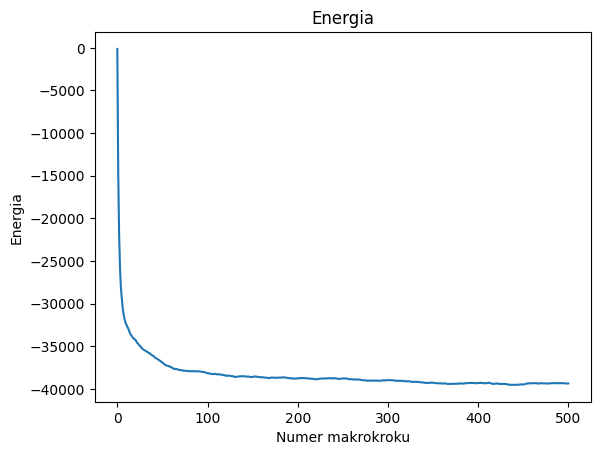

In [24]:
xh = np.arange(0,step_count+1)
yh = []

for i in range(step_count+1):
    yh.append(hamiltonian(states[i],J,B))

plt.plot(xh,yh)
plt.title('Energia')
plt.xlabel('Numer makrokroku')
plt.ylabel('Energia')
plt.show